<img src="../assets/header.gif" style="width:100%">
<hr style="color:#808080;">
<p align="center"><b>A L B U S</b></p>
<hr style="color:#808080;">

A demonstration notebook for our library **Albus** on a Black Sea oxygen forecast sample.

In [1]:
import torch
import matplotlib.pyplot as plt

mask     = torch.load("notebook/data/mask.pt",       weights_only=True)
truth    = torch.load("notebook/data/o-truth.pt",    weights_only=True)
forecast = torch.load("notebook/data/o-forecast.pt", weights_only=True)

# Adjusting shape of ground truth to match forecast shape
truth = truth.unsqueeze(1)

print("(T, N, C, Y, X) = (Time, Ensemble, Levels, Latitude, Longitude)")
print("|")
print(f"mask     : {tuple(mask.shape)}")
print(f"truth    : {tuple(truth.shape)}")
print(f"forecast : {tuple(forecast.shape)}")

# Stuff for plotting
DEPTHS      = ["0.25 [m]", "9 [m]"]
LEAD_TIMES  = range(1, truth.shape[0] + 1)

(T, N, C, Y, X) = (Time, Ensemble, Levels, Latitude, Longitude)
|
mask     : (128, 256)
truth    : (7, 1, 2, 128, 256)
forecast : (7, 4, 2, 128, 256)


<hr style="color:#808080;">
<p align="center"><b>M E T R I C S</b></p>
<hr style="color:#808080;">

In [2]:
from albus.metrics import (
    continuous_ranked_probability_score,
    mean_square_error,
    power_spectrum,
    root_mean_square_error,
    skill,
    spread,
    spread_skill_ratio,
    standard_deviation,
)

mse = mean_square_error(
    x=truth,
    y=forecast,
    dims="T N C Y X",
    reduce="N Y X",
    mask=mask,
)

rmse = root_mean_square_error(
    x=truth,
    y=forecast,
    dims="T N C Y X",
    reduce="N Y X",
    mask=mask,
)

std = standard_deviation(
    x=forecast,
    dims="T N C Y X",
    reduce="N Y X",
    mask=mask,
)

sk = skill(
    x=truth.squeeze(1),
    y=forecast,
    dims="T N C Y X",
    ensemble="N",
    reduce="Y X",
    mask=mask,
)

sp = spread(
    x=forecast,
    dims="T N C Y X",
    ensemble="N",
    reduce="Y X",
    mask=mask,
)

_, _, ratio = spread_skill_ratio(
    x=truth.squeeze(1),
    y=forecast,
    dims="T N C Y X",
    ensemble="N",
    reduce="Y X",
    mask=mask,
)

crps = continuous_ranked_probability_score(
    x=truth.squeeze(1),
    y=forecast,
    dims="T N C Y X",
    ensemble="N",
    reduce="Y X",
    mask=mask,
)

spectrum_truth = power_spectrum(
    x=truth.squeeze(1),
    dims="T C Y X",
    spatial="Y X",
    mask=mask,
)

spectrum_forecast = power_spectrum(
    x=forecast.nanmean(dim=1),
    dims="T C Y X",
    spatial="Y X",
    mask=mask,
)


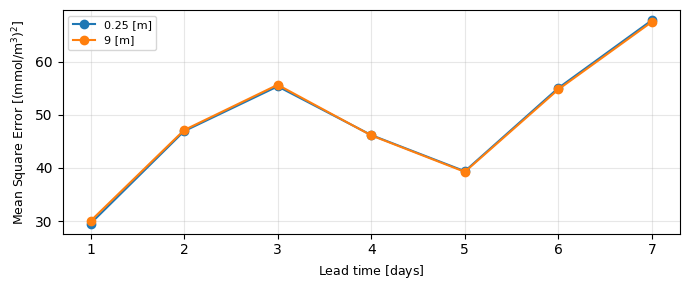

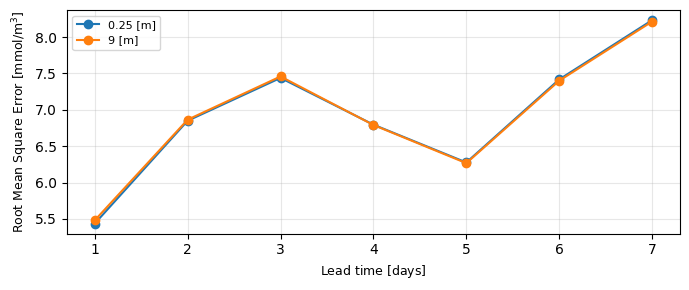

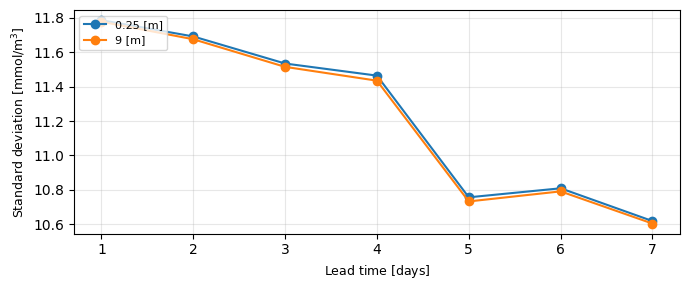

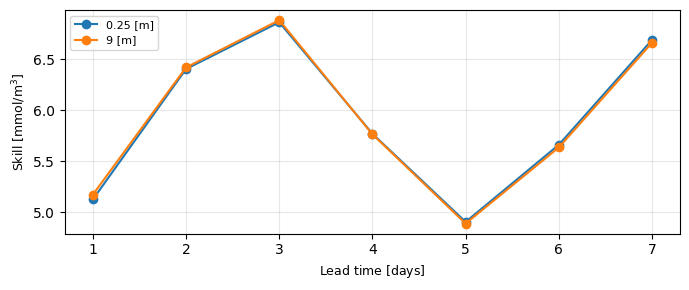

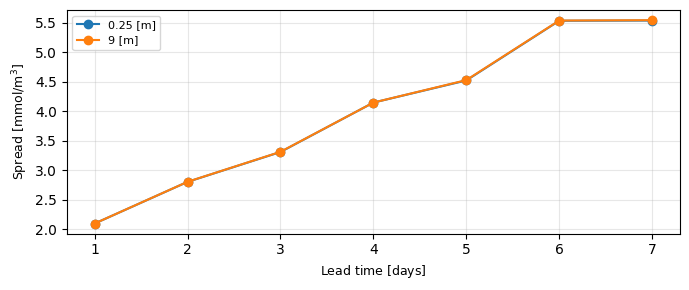

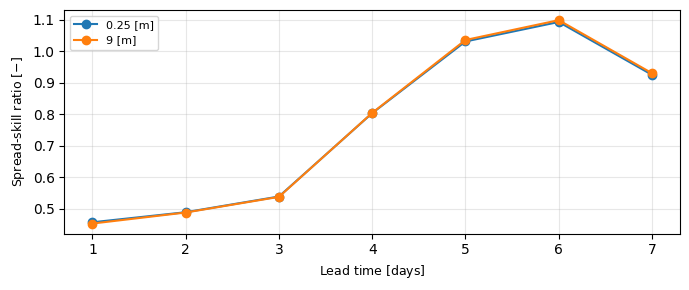

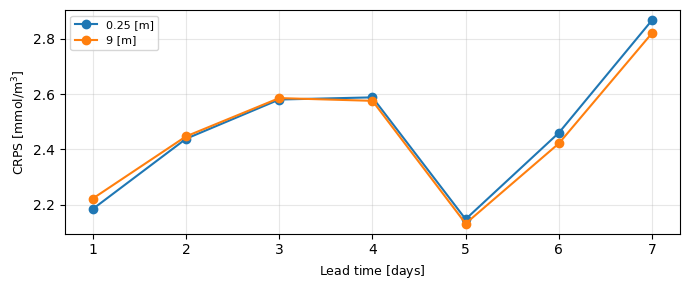

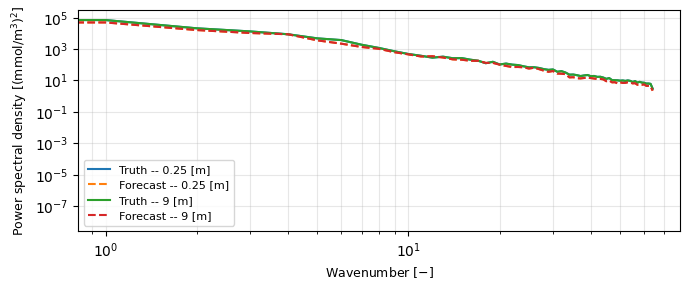

In [3]:
def plot_lead_time(values: torch.Tensor, ylabel: str, unit: str) -> None:
    r"""Plot a (T, C) metric tensor against lead time, one line per depth."""
    fig, ax = plt.subplots(figsize=(7, 3))
    for c, depth in enumerate(DEPTHS):
        ax.plot(LEAD_TIMES, values[:, c].numpy(), marker="o", label=depth)
    ax.set_xlabel(r"Lead time [$\mathrm{days}$]", fontsize=9)
    ax.set_ylabel(rf"{ylabel} [${unit}$]", fontsize=9)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_spectrum(truth: torch.Tensor, forecast: torch.Tensor, lead_time: int = -1) -> None:
    r"""Plot the isotropic power spectra of the truth and the ensemble-mean forecast, one line per depth."""
    fig, ax = plt.subplots(figsize=(7, 3))
    for c, depth in enumerate(DEPTHS):
        ax.loglog(truth[lead_time, c].numpy(), label=f"Truth -- {depth}")
        ax.loglog(forecast[lead_time, c].numpy(), linestyle="--", label=f"Forecast -- {depth}")
    ax.set_xlabel(r"Wavenumber [$-$]", fontsize=9)
    ax.set_ylabel(r"Power spectral density [$\mathrm{(mmol/m^3)^2}$]", fontsize=9)
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_lead_time(mse, "Mean Square Error", r"\mathrm{(mmol/m^3)^2}")
plot_lead_time(rmse, "Root Mean Square Error", r"\mathrm{mmol/m^3}")
plot_lead_time(std, "Standard deviation", r"\mathrm{mmol/m^3}")
plot_lead_time(sk, "Skill", r"\mathrm{mmol/m^3}")
plot_lead_time(sp, "Spread", r"\mathrm{mmol/m^3}")
plot_lead_time(ratio, "Spread-skill ratio", r"-")
plot_lead_time(crps, "CRPS", r"\mathrm{mmol/m^3}")
plot_spectrum(spectrum_truth, spectrum_forecast)


<hr style="color:#808080;">
<p align="center"><b>O X Y G E N</b></p>
<hr style="color:#808080;">

In [4]:
from albus.ocean.oxygen import hypoxia

threshold = 287.0
# Note: The physical hypoxia threshold (~63 mmol/m^3) never triggers on this sample (min ~191 mmol/m^3)
#       using a threshold within the observed range purely to illustrate the classification metrics. 

out = hypoxia(
    x=truth,
    y=forecast,
    dims="T N C Y X",
    reduce="N Y X",
    thresholds=[threshold, threshold],
    thresholds_curve=torch.linspace(190.0, 380.0, 20).tolist(),
    mask=mask,
)


Generating Curves:   0%|          | 0/14 [00:00<?, ?it/s]

Generating Curves:   7%|▋         | 1/14 [00:01<00:21,  1.64s/it]

Generating Curves:  14%|█▍        | 2/14 [00:03<00:19,  1.59s/it]

Generating Curves:  21%|██▏       | 3/14 [00:04<00:17,  1.58s/it]

Generating Curves:  29%|██▊       | 4/14 [00:06<00:15,  1.57s/it]

...

Generating Curves:  71%|███████▏  | 10/14 [00:15<00:06,  1.58s/it]

Generating Curves:  79%|███████▊  | 11/14 [00:17<00:04,  1.58s/it]

Generating Curves:  86%|████████▌ | 12/14 [00:18<00:03,  1.58s/it]

Generating Curves:  93%|█████████▎| 13/14 [00:20<00:01,  1.59s/it]

Generating Curves: 100%|██████████| 14/14 [00:22<00:00,  1.59s/it]

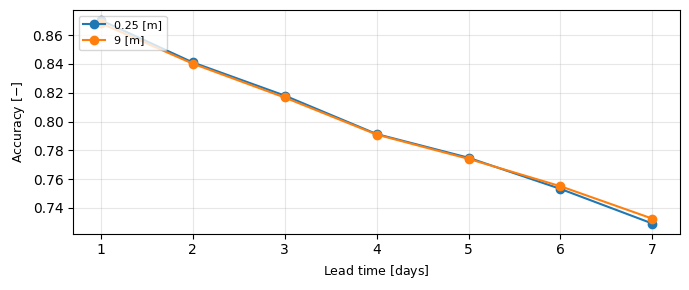

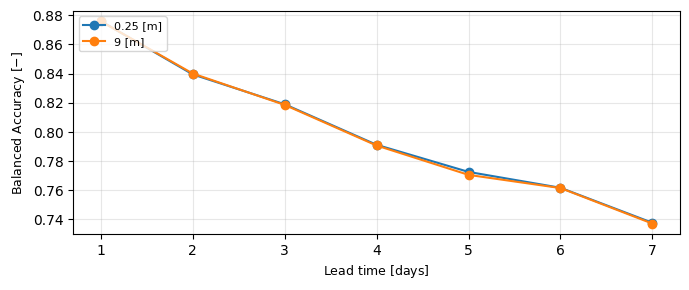

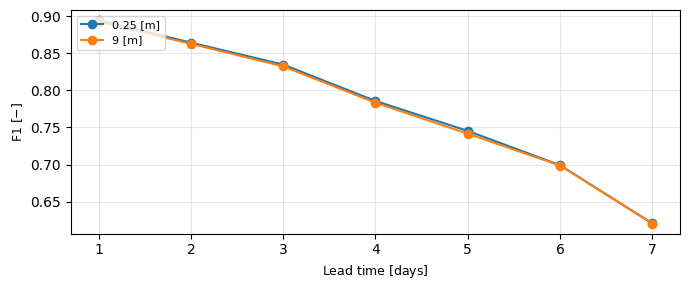

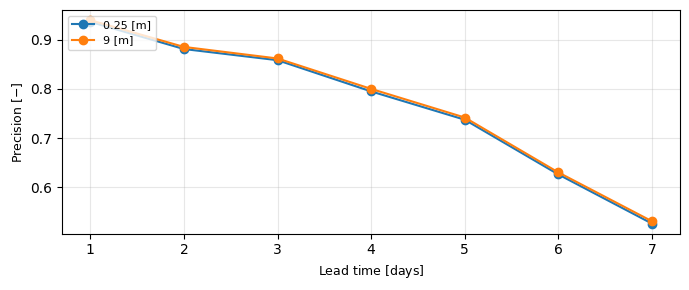

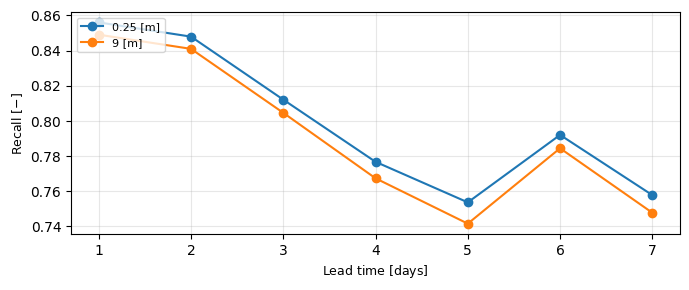

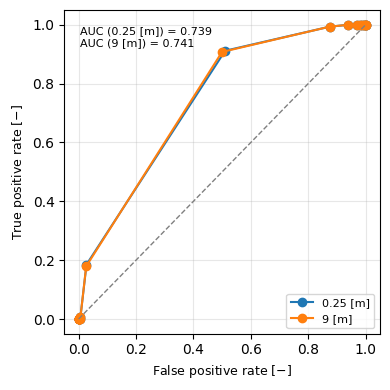

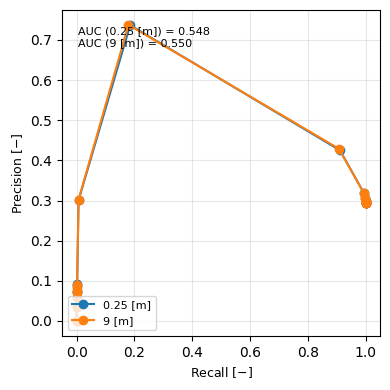

In [5]:
def plot_roc(out: dict, lead_time: int = -1) -> None:
    r"""Plot the ROC curve (false vs. true positive rate) for a given lead time, one line per depth."""
    fig, ax = plt.subplots(figsize=(4, 4))
    for c, depth in enumerate(DEPTHS):
        ax.plot(
            out["roc_fpr"][:, lead_time, c].numpy(),
            out["roc_tpr"][:, lead_time, c].numpy(),
            marker="o",
            label=depth,
        )
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    auc_text = "\n".join(f"AUC ({depth}) = {out['roc_auc'][lead_time, c]:.3f}" for c, depth in enumerate(DEPTHS))
    ax.text(0.05, 0.95, auc_text, transform=ax.transAxes, fontsize=8, va="top", ha="left")
    ax.set_xlabel(r"False positive rate [$-$]", fontsize=9)
    ax.set_ylabel(r"True positive rate [$-$]", fontsize=9)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_precision_recall(out: dict, lead_time: int = -1) -> None:
    r"""Plot the precision-recall curve for a given lead time, one line per depth."""
    fig, ax = plt.subplots(figsize=(4, 4))
    for c, depth in enumerate(DEPTHS):
        ax.plot(
            out["pr_recall"][:, lead_time, c].numpy(),
            out["pr_precision"][:, lead_time, c].numpy(),
            marker="o",
            label=depth,
        )
    auc_text = "\n".join(f"AUC ({depth}) = {out['pr_auc'][lead_time, c]:.3f}" for c, depth in enumerate(DEPTHS))
    ax.text(0.05, 0.95, auc_text, transform=ax.transAxes, fontsize=8, va="top", ha="left")
    ax.set_xlabel(r"Recall [$-$]", fontsize=9)
    ax.set_ylabel(r"Precision [$-$]", fontsize=9)
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for key in ("accuracy", "balanced_accuracy", "f1", "precision", "recall"):
    plot_lead_time(out[key], key.replace("_", " ").title(), r"-")

plot_roc(out)
plot_precision_recall(out)
